In [1]:
# ==============================================================================
# 1. Import Necessary Libraries
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

In [2]:
# Set plotting style for clear, professional visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# ==============================================================================
# 2. Download and Load the Dataset via Kagglehub
# ==============================================================================
print("Downloading dataset from Kaggle...")
# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download("pratyushpuri/financial-news-market-events-dataset-2025")

print(f"Dataset downloaded to cache: {dataset_path}")

# Dynamically find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded Kaggle dataset.")

# Assuming the main data is in the first CSV found
file_path = os.path.join(dataset_path, csv_files[0])
df = pd.read_csv(file_path)

# Quick sanity check on shape
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

Dataset downloaded to cache: /Users/tajsharma/.cache/kagglehub/datasets/pratyushpuri/financial-news-market-events-dataset-2025/versions/1

Dataset Shape: 3024 rows, 12 columns



In [4]:
# ==============================================================================
# 3. Initial Data Quality & Null Inspection
# ==============================================================================
print("--- Percentage of Missing Values per Column ---")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

--- Percentage of Missing Values per Column ---
Sentiment               5.654762
Index_Change_Percent    5.324074
News_Url                5.059524
Headline                4.894180
dtype: float64


In [5]:
# ==============================================================================
# 4. Systematically Handling the 5% Null Rate
# ==============================================================================
df_cleaned = df.copy()

# Drop rows where the actual 'Headline' is missing (required for NLP/Context)
if 'Headline' in df_cleaned.columns:
    df_cleaned.dropna(subset=['Headline'], inplace=True)

# Separate categorical and numerical columns for systematic imputation
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns

# Impute Categorical Columns with 'Unknown'
for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# Impute Numerical Columns with Median
for col in numerical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Final Verification
print("\n--- Missing Values Post-Cleaning ---")
print(df_cleaned.isnull().sum())
print(f"\nFinal Cleaned Dataset Shape: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns")


--- Missing Values Post-Cleaning ---
Date                    0
Headline                0
Source                  0
Market_Event            0
Market_Index            0
Index_Change_Percent    0
Trading_Volume          0
Sentiment               0
Sector                  0
Impact_Level            0
Related_Company         0
News_Url                0
dtype: int64

Final Cleaned Dataset Shape: 2876 rows, 12 columns


/var/folders/k5/1ys4jvv95zv528gdmtsrb7s80000gn/T/ipykernel_58065/472053604.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_cleaned.select_dtypes(include=['object']).columns


In [6]:
# ==============================================================================
# 5. Feature Engineering: Volatility Magnitude
# ==============================================================================
# In volatility trading, the direction matters less than the magnitude of the move.
# We create an absolute change column to measure pure reactivity.
df_cleaned['Abs_Index_Change_Percent'] = df_cleaned['Index_Change_Percent'].abs()

In [7]:
# ==============================================================================
# 6. Event Category Impact: Aggregated Metrics
# ==============================================================================
print("--- Summary Statistics by Market Event ---")
event_summary = df_cleaned.groupby('Market_Event').agg(
    Event_Count=('Market_Event', 'count'),
    Median_Volume=('Trading_Volume', 'median'),
    Mean_Abs_Price_Change=('Abs_Index_Change_Percent', 'mean'),
    Max_Abs_Price_Change=('Abs_Index_Change_Percent', 'max')
).sort_values(by='Mean_Abs_Price_Change', ascending=False)

print(event_summary,"\n")

--- Summary Statistics by Market Event ---
                                Event_Count  Median_Volume  \
Market_Event                                                 
Inflation Data Release                  139        223.550   
Geopolitical Event                      132        237.845   
Currency Devaluation                    130        219.315   
Central Bank Meeting                    151        251.630   
Regulatory Changes                      140        232.595   
IPO Launch                              140        258.500   
Market Rally                            171        250.190   
Interest Rate Change                    157        256.710   
Major Merger/Acquisition                149        254.240   
Trade Tariffs Announcement              143        219.310   
Stock Market Crash                      132        248.855   
Commodity Price Shock                   163        258.400   
Unemployment Rate Announcement          139        237.570   
Cryptocurrency Regulation  

/var/folders/k5/1ys4jvv95zv528gdmtsrb7s80000gn/T/ipykernel_58065/1482097889.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/k5/1ys4jvv95zv528gdmtsrb7s80000gn/T/ipykernel_58065/1482097889.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


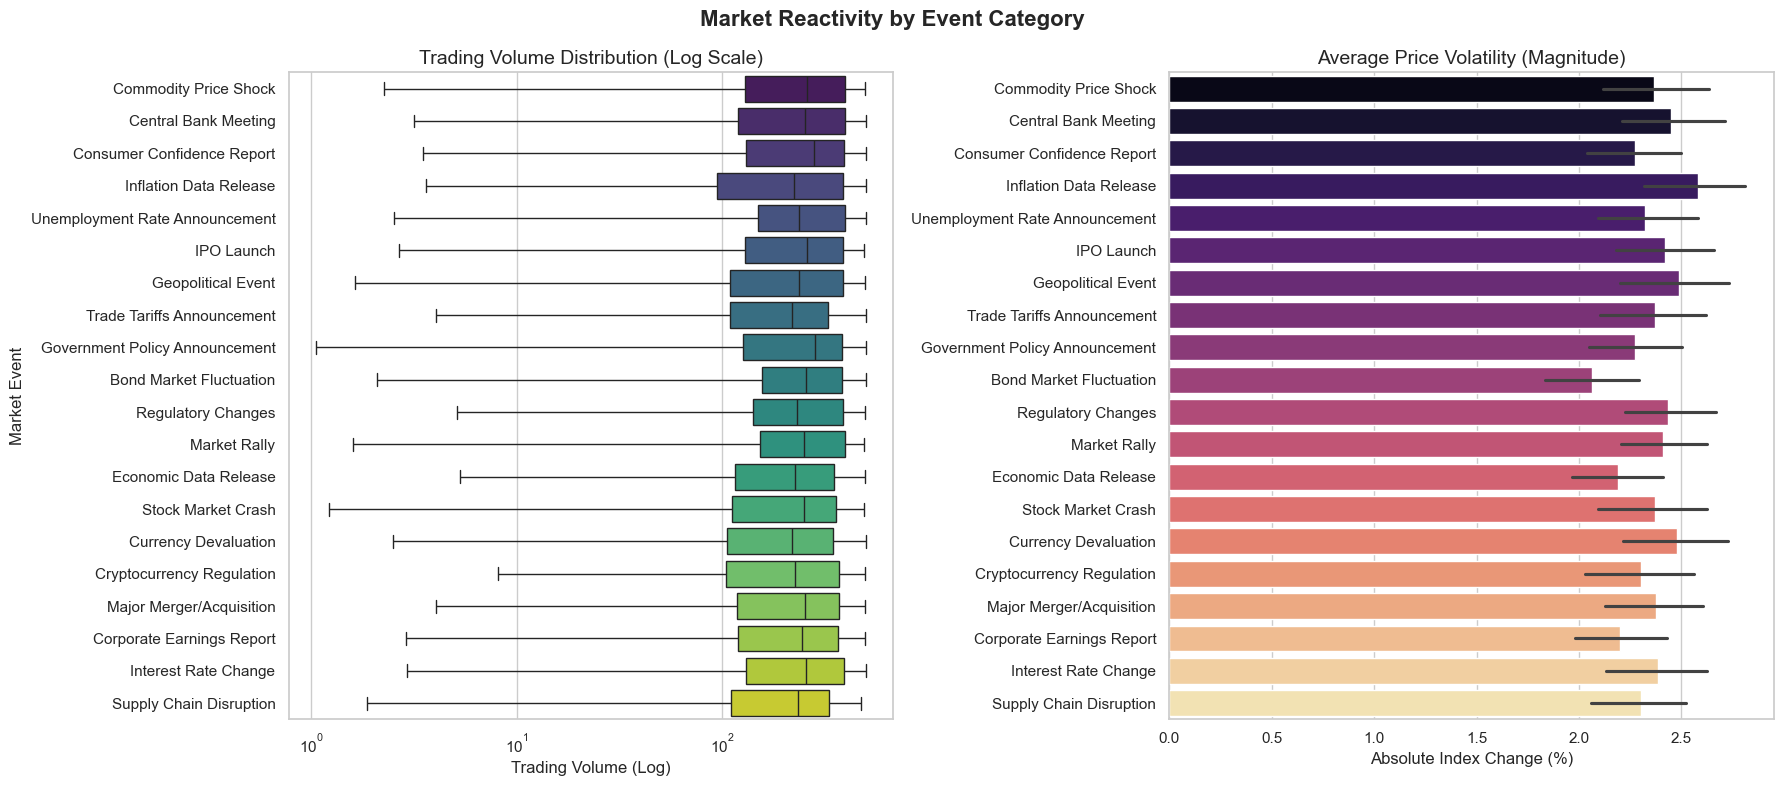

In [8]:
# ==============================================================================
# 7. Visualizing Market Reactivity by Event Type
# ==============================================================================
# Set up a 1x2 grid for our visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Market Reactivity by Event Category', fontsize=16, fontweight='bold')

# Plot 1: Trading Volume Distributions (Log Scale due to typical financial data skew)
# We use a boxplot to clearly see medians and the spread of outliers (anomalies).
sns.boxplot(
    data=df_cleaned, 
    x='Trading_Volume', 
    y='Market_Event', 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_xscale('log') # Log scale helps visualize heavy-tailed volume data
axes[0].set_title('Trading Volume Distribution (Log Scale)', fontsize=14)
axes[0].set_xlabel('Trading Volume (Log)')
axes[0].set_ylabel('Market Event')

# Plot 2: Average Magnitude of Price Swings
sns.barplot(
    data=df_cleaned, 
    x='Abs_Index_Change_Percent', 
    y='Market_Event', 
    ax=axes[1], 
    palette='magma',
    errorbar=('ci', 95) # 95% Confidence Interval to show variance reliability
)
axes[1].set_title('Average Price Volatility (Magnitude)', fontsize=14)
axes[1].set_xlabel('Absolute Index Change (%)')
axes[1].set_ylabel('') # Hide y-label as it shares the same categories as Plot 1

plt.tight_layout()
plt.show()

In [9]:
# ==============================================================================
# 8. Sector Sensitivity: Aggregated Metrics
# ==============================================================================
print("--- Volatility Metrics by Sector ---")
sector_summary = df_cleaned.groupby('Sector').agg(
    Article_Count=('Sector', 'count'),
    Median_Volume=('Trading_Volume', 'median'),
    Mean_Abs_Price_Change=('Abs_Index_Change_Percent', 'mean')
).sort_values(by='Mean_Abs_Price_Change', ascending=False)

print(sector_summary)

--- Volatility Metrics by Sector ---
                       Article_Count  Median_Volume  Mean_Abs_Price_Change
Sector                                                                    
Telecommunications               158        243.590               2.590696
Media & Entertainment            158        317.545               2.497848
Technology                       170        241.160               2.476353
Energy                           158        243.105               2.457595
Utilities                        162        266.445               2.420802
Materials                        163        244.980               2.418589
Aerospace & Defense              155        229.530               2.370065
Healthcare                       150        222.255               2.354400
Retail                           158        235.585               2.334177
Finance                          145        246.840               2.333069
Automotive                       169        230.810            

/var/folders/k5/1ys4jvv95zv528gdmtsrb7s80000gn/T/ipykernel_58065/712423692.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/k5/1ys4jvv95zv528gdmtsrb7s80000gn/T/ipykernel_58065/712423692.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


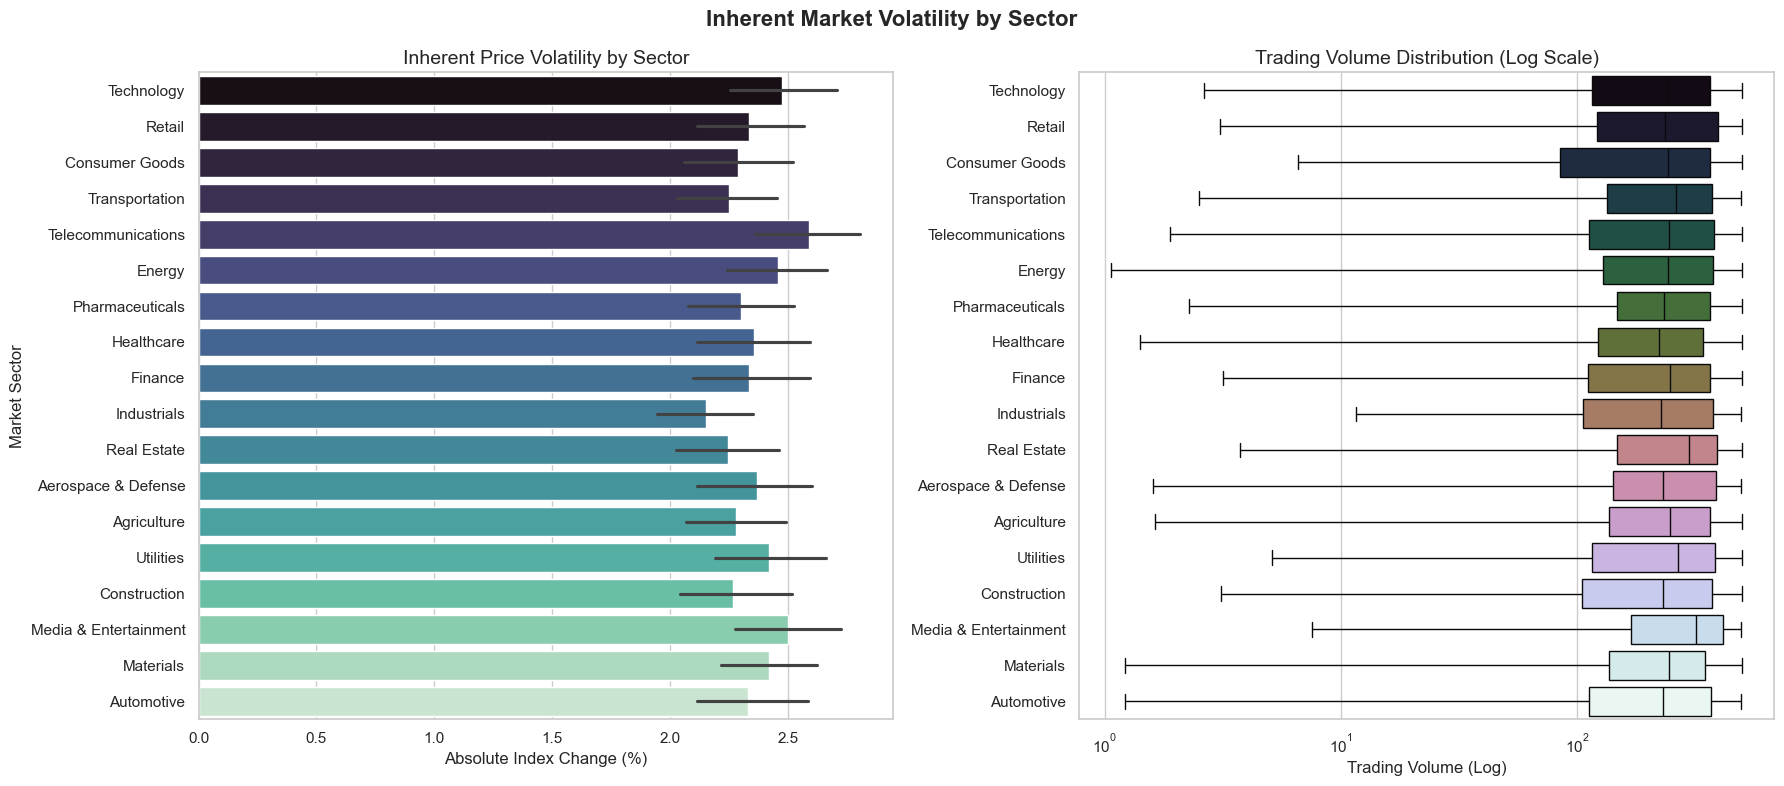

In [10]:
# ==============================================================================
# 9. Visualizing Sector Sensitivity
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Inherent Market Volatility by Sector', fontsize=16, fontweight='bold')

# Plot 1: Average Price Volatility by Sector
sns.barplot(
    data=df_cleaned, 
    x='Abs_Index_Change_Percent', 
    y='Sector', 
    ax=axes[0], 
    palette='mako',
    errorbar=('ci', 95)
)
axes[0].set_title('Inherent Price Volatility by Sector', fontsize=14)
axes[0].set_xlabel('Absolute Index Change (%)')
axes[0].set_ylabel('Market Sector')

# Plot 2: Trading Volume Distribution by Sector
sns.boxplot(
    data=df_cleaned, 
    x='Trading_Volume', 
    y='Sector', 
    ax=axes[1], 
    palette='cubehelix'
)
axes[1].set_xscale('log')
axes[1].set_title('Trading Volume Distribution (Log Scale)', fontsize=14)
axes[1].set_xlabel('Trading Volume (Log)')
axes[1].set_ylabel('') # Hide y-label for a cleaner look as it shares the left axis

plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# 10. Sentiment Directionality: Aggregated Metrics
# ==============================================================================
print("--- Volatility Metrics by Sentiment ---")
sentiment_summary = df_cleaned.groupby('Sentiment').agg(
    Article_Count=('Sentiment', 'count'),
    Median_Volume=('Trading_Volume', 'median'),
    Mean_Abs_Price_Change=('Abs_Index_Change_Percent', 'mean')
).sort_values(by='Mean_Abs_Price_Change', ascending=False)

print(sentiment_summary)

--- Volatility Metrics by Sentiment ---
           Article_Count  Median_Volume  Mean_Abs_Price_Change
Sentiment                                                     
Negative             926        244.305               2.403488
Positive             882        242.015               2.342302
Unknown              162        266.455               2.328704
Neutral              906        242.480               2.316203


/var/folders/k5/1ys4jvv95zv528gdmtsrb7s80000gn/T/ipykernel_58065/1212560917.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/k5/1ys4jvv95zv528gdmtsrb7s80000gn/T/ipykernel_58065/1212560917.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


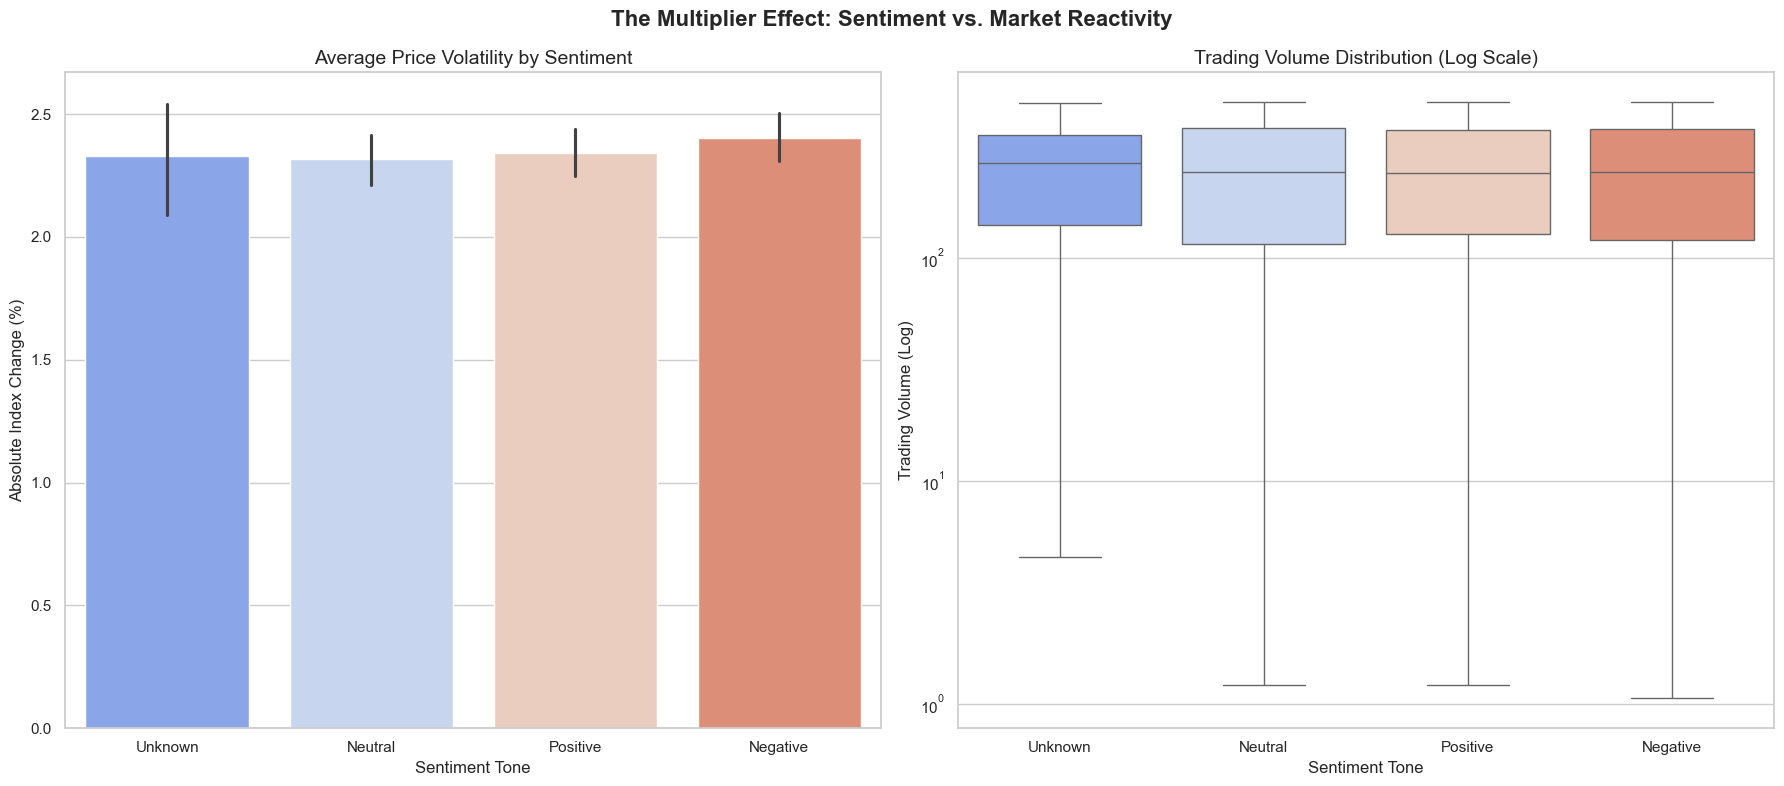

In [12]:
# ==============================================================================
# 11. Visualizing Sentiment Impact on Market Reactivity
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('The Multiplier Effect: Sentiment vs. Market Reactivity', fontsize=16, fontweight='bold')

# Plot 1: Price Volatility by Sentiment Tone
sns.barplot(
    data=df_cleaned,
    x='Sentiment',
    y='Abs_Index_Change_Percent',
    ax=axes[0],
    palette='coolwarm',
    errorbar=('ci', 95)
)
axes[0].set_title('Average Price Volatility by Sentiment', fontsize=14)
axes[0].set_xlabel('Sentiment Tone')
axes[0].set_ylabel('Absolute Index Change (%)')

# Plot 2: Trading Volume Distribution by Sentiment
# Using yscale('log') here since Sentiment is on the x-axis
sns.boxplot(
    data=df_cleaned,
    x='Sentiment',
    y='Trading_Volume',
    ax=axes[1],
    palette='coolwarm'
)
axes[1].set_yscale('log')
axes[1].set_title('Trading Volume Distribution (Log Scale)', fontsize=14)
axes[1].set_xlabel('Sentiment Tone')
axes[1].set_ylabel('Trading Volume (Log)')

plt.tight_layout()
plt.show()

In [13]:
#export cleaned dataset for Tableau presentation
df_cleaned.to_csv('financial_news_cleaned.csv', index = False)